# 2. Dataset Preprocessing

In this notebook we first need to analyze the bacteria genera present in each patients gut microbiome before proceeding to the main project analysis. The steps we perform are explained during the process.

In [1]:
# import and load the baseline data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the processed baseline files we saved in notebook 01
meta = pd.read_csv("../data/processed/metadata_baseline.tsv", sep="\t")
genera = pd.read_csv("../data/processed/genera_baseline.tsv", sep="\t", index_col=0)

print("Metadata shape:", meta.shape)
print("Genera shape:", genera.shape)

Metadata shape: (105, 24)
Genera shape: (105, 9694)


## Step 0: Sparsity 

Many of the values are expected to be zero. This means that for most of the patients will not have all bacteria in their gut, having a few active onew only. Zero-heavy data could cause issues in statistic analysis and/or the ML models we plan to use later in the project.

In [2]:
# What fraction of the genera table is zero?
sparsity = (genera == 0).sum().sum() / genera.size
print(f"Sparsity: {sparsity:.1%} of values are zero")

# How many genera are present in at least 10% of samples?
min_prevalence = 0.10
prevalence = (genera > 0).mean()
kept = (prevalence >= min_prevalence).sum()
print(f"Genera present in at least 10% of samples: {kept} / {genera.shape[1]}")

Sparsity: 84.7% of values are zero
Genera present in at least 10% of samples: 2761 / 9694


## Step 1: Filtering

The rare genera (present in less than 10% of the samples) are not as meaningful as the rest. We drop any genus that we classify as "rare".

In [3]:
# Keep only genera present in at least 10% of samples
prevalence = (genera > 0).mean()
genera_filtered = genera.loc[:, prevalence >= 0.10]

print(f"Before filtering: {genera.shape[1]} genera")
print(f"After filtering:  {genera_filtered.shape[1]} genera")
print(f"Removed:          {genera.shape[1] - genera_filtered.shape[1]} rare genera")

Before filtering: 9694 genera
After filtering:  2761 genera
Removed:          6933 rare genera


## Step 2: Normalize

We need to normalize the dataset, so that for every patient the bacteria percentage sums to 1.0 (100%).

In [4]:
# Each row (sample) should sum to 1.0
row_sums = genera_filtered.sum(axis=1)
print("Row sums before normalization:")
print(row_sums.describe().round(4))

# Normalize
genera_norm = genera_filtered.div(row_sums, axis=0)

print("\nRow sums after normalization:")
print(genera_norm.sum(axis=1).describe().round(4))

Row sums before normalization:
count    105.0000
mean       0.9997
std        0.0004
min        0.9963
25%        0.9997
50%        0.9998
75%        0.9999
max        0.9999
dtype: float64

Row sums after normalization:
count    105.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64


## Step 3: CLR (Centered log-ratio) transform

$$
\mathrm{CLR}(x_i) = \log\left( \frac{x_i}{g(x)} \right)
\quad \text{where} \quad
g(x) = \left( \prod_{j=1}^{D} x_j \right)^{1/D}
$$

Why do we do CLR transform?

* Changes in raw abundances in microbiome data are not always well represented on a linear scale. The log transform converts multiplicative differences into additive ones.

* The centered part makes sure each value represents how each abundance compares to the average abundance. It helps with ratios comparisons.

* Raw abundances sum to one causing false constraints.

* All of the above result in better use of mathematical transforms like PCA.

In [5]:
# CLR = log(x / geometric_mean(row))
# We add a small pseudocount to avoid log(0)
pseudocount = 1e-6

def clr_transform(df):
    log_df = np.log(df + pseudocount)
    geometric_mean = log_df.mean(axis=1)  # mean of logs = log of geometric mean
    return log_df.subtract(geometric_mean, axis=0)

genera_clr = clr_transform(genera_norm)

print("CLR transformed data:")
print(genera_clr.shape)
print(genera_clr.describe().round(3))

CLR transformed data:
(105, 2761)
       d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__Flemingibacterium  \
count                                            105.000                                              
mean                                               0.701                                              
std                                                1.625                                              
min                                               -1.074                                              
25%                                               -0.272                                              
50%                                                0.124                                              
75%                                                0.786                                              
max                                                5.882                                              

       d__Bacteria;p__Firmicutes_A;c__

## Step 4: Plot the effect of the CLR transform

On the raw data the most values are near zero and a few are very large. After applying the transform the data have a bell-shaped format which is more suitable for analysis with ML models.

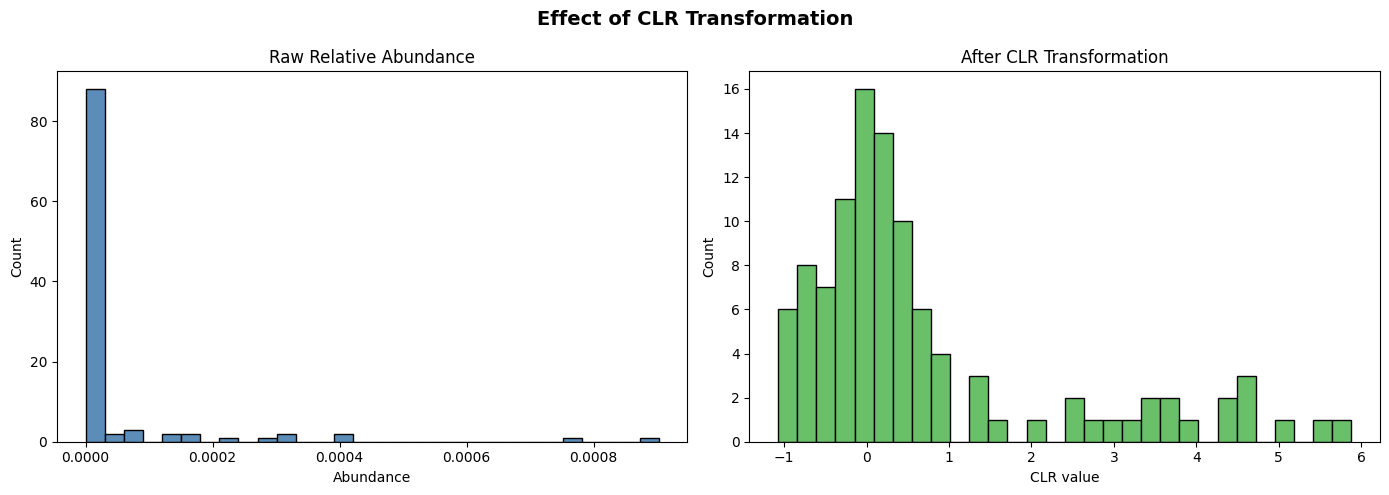

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of CLR Transformation", fontsize=14, fontweight="bold")

# Pick one genus to illustrate
example_genus = genera_norm.columns[0]

axes[0].hist(genera_norm[example_genus], bins=30, color="#5b8db8", edgecolor="black")
axes[0].set_title("Raw Relative Abundance")
axes[0].set_xlabel("Abundance")
axes[0].set_ylabel("Count")

axes[1].hist(genera_clr[example_genus], bins=30, color="#6abf69", edgecolor="black")
axes[1].set_title("After CLR Transformation")
axes[1].set_xlabel("CLR value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../results/figures/07_clr_transformation.png", dpi=150)
plt.show()

## Step 5: Save to the processed data folder

In [7]:
# Align metadata index with genera index just to be safe
meta = meta.set_index("Sample")
meta = meta.loc[genera_clr.index]

# Save
genera_clr.to_csv("../data/processed/genera_clr.tsv", sep="\t")
meta.to_csv("../data/processed/metadata_final.tsv", sep="\t")

print("Saved:")
print("  data/processed/genera_clr.tsv")
print("  data/processed/metadata_final.tsv")
print(f"\nFinal dataset: {genera_clr.shape[0]} subjects × {genera_clr.shape[1]} genera")

Saved:
  data/processed/genera_clr.tsv
  data/processed/metadata_final.tsv

Final dataset: 105 subjects × 2761 genera
